In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets


%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

In [4]:
def load_dataset():
    np.random.seed(1)
    train_X, train_Y = sklearn.datasets.make_circles(n_samples=300, noise=.05)
    np.random.seed(2)
    test_X, test_Y = sklearn.datasets.make_circles(n_samples=100, noise=.05)
    # Visualize the data
    plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y, s=40, cmap=plt.cm.Spectral);
    train_X = train_X.T
    train_Y = train_Y.reshape((1, train_Y.shape[0]))
    test_X = test_X.T
    test_Y = test_Y.reshape((1, test_Y.shape[0]))
    return train_X, train_Y, test_X, test_Y

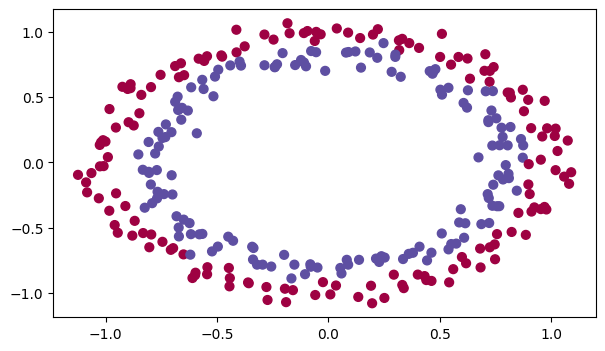

In [5]:
train_X, train_Y, test_X, test_Y = load_dataset()

Before we proceed with this let us define activation functions and forward and bacward propagation

In [6]:
def sigmoid(z):
    s = 1/(1 + np.exp(-z))
    return s

In [8]:
def relu(x):
    a = np.maximum(0, x)
    return a

In [16]:
def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    z1 = np.dot(W1, X) + b1
    a1 = relu(z1)
    z2 = np.dot(W2, a1) + b2
    a2 = relu(z2)
    z3 = np.dot(W3, a2) + b3
    a3 = sigmoid(z3)

    cache = (z1, a1, W1, b1, z2, a2, W2, b2, z3, a3, W3, b3)

    return a3, cache

In [17]:
def backward_propagation(X, Y, cache):
    m = X.shape[1]
    (z1, a1, W1, b1, z2, a2, W2, b2, z3, a3, W3, b3) = cache

    dz3 = 1./m * (a3 - Y)
    dW3 = np.dot(dz3, a2.T)
    db3 = np.sum(dz3, axis=1, keepdims = True)
    
    da2 = np.dot(W3.T, dz3)
    dz2 = np.multiply(da2, np.int64(a2 > 0))
    dW2 = np.dot(dz2, a1.T)
    db2 = np.sum(dz2, axis=1, keepdims = True)
    
    da1 = np.dot(W2.T, dz2)
    dz1 = np.multiply(da1, np.int64(a1 > 0))
    dW1 = np.dot(dz1, X.T)
    db1 = np.sum(dz1, axis=1, keepdims = True)
    
    gradients = {"dz3": dz3, "dW3": dW3, "db3": db3,
                 "da2": da2, "dz2": dz2, "dW2": dW2, "db2": db2,
                 "da1": da1, "dz1": dz1, "dW1": dW1, "db1": db1}
    
    return gradients

In [18]:
def update_parameters(parameters, grads, learning_rate):
    L = len(parameters)//2

    for k in range(L):
        parameters["W" + str(k+1)] = parameters["W" + str(k+1)] - learning_rate * grads["dW" + str(k+1)]
        parameters["b" + str(k+1)] = parameters["b" + str(k+1)] - learning_rate * grads["db" + str(k+1)]

    return parameters

In [19]:
def compute_cost(a3, Y):
    m = Y.shape[1]
    logprobs = np.multiply(-np.log(a3),Y) + np.multiply(-np.log(1 - a3), 1 - Y)
    loss = 1./m * np.nansum(logprobs)
    
    return loss

In [27]:
def predict(X, y, parameters):
    m = X.shape[1]
    p = np.zeros((1,m), dtype = int)
    
    a3, caches = forward_propagation(X, parameters)
    
    for i in range(0, a3.shape[1]):
        if a3[0,i] > 0.5:
            p[0,i] = 1
        else:
            p[0,i] = 0

    print("Accuracy: "  + str(np.mean((p[0,:] == y[0,:]))))
    
    return p

In [28]:
def model(X, Y, learning_rate = 0.01, num_iterations = 15000, print_cost = True, initialization = "he"):
    grads = {}
    costs = []
    m = X.shape[1]
    layers_dims = [X.shape[0], 10, 5, 1]

    if initialization == "zeros":
        parameters = initialize_parameters_zeros(layers_dims)
    elif initialization == "random":
        parameters = initialize_parameters_random(layers_dims)
    elif initialization == "he":
        parameters = initialize_parameters_he(layers_dims)
    

    for i in range(num_iterations):
        a3, cache = forward_propagation(X, parameters)
        cost = compute_cost(a3, Y)
        grads = backward_propagation(X, Y, cache)
        parameters = update_parameters(parameters, grads, learning_rate)

        if print_cost and i%1000 == 0:
            print("Cost after interation {} : {}".format(i, cost))
            costs.append(cost)

    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel("iterations (per hundreds)")
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters

In [29]:
def initialize_parameters_zeros(layers_dims):
    parameters = {}
    L = len(layers_dims)

    for l in range(1, L):
        parameters['W' + str(l)] = np.zeros((layers_dims[l], layers_dims[l-1]))
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))

    return parameters

Cost after interation 0 : 0.6931471805599453
Cost after interation 1000 : 0.6931471805599453
Cost after interation 2000 : 0.6931471805599453
Cost after interation 3000 : 0.6931471805599453
Cost after interation 4000 : 0.6931471805599453
Cost after interation 5000 : 0.6931471805599453
Cost after interation 6000 : 0.6931471805599453
Cost after interation 7000 : 0.6931471805599453
Cost after interation 8000 : 0.6931471805599453
Cost after interation 9000 : 0.6931471805599453
Cost after interation 10000 : 0.6931471805599455
Cost after interation 11000 : 0.6931471805599453
Cost after interation 12000 : 0.6931471805599453
Cost after interation 13000 : 0.6931471805599453
Cost after interation 14000 : 0.6931471805599453


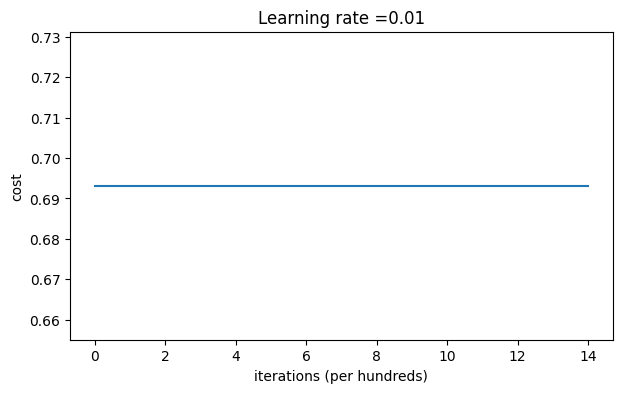

On the train set:
Accuracy: 0.5
On the test set:
Accuracy: 0.5


In [30]:
parameters = model(train_X, train_Y, initialization = "zeros")
print ("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

In [31]:
def initialize_parameters_random(layers_dims):
    np.random.seed(3)
    parameters = {}
    L = len(layers_dims)

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1])*10
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))

    return parameters

/tmp/ipykernel_1098/1832363181.py:3: RuntimeWarning: divide by zero encountered in log
  logprobs = np.multiply(-np.log(a3),Y) + np.multiply(-np.log(1 - a3), 1 - Y)
/tmp/ipykernel_1098/1832363181.py:3: RuntimeWarning: invalid value encountered in multiply
  logprobs = np.multiply(-np.log(a3),Y) + np.multiply(-np.log(1 - a3), 1 - Y)


Cost after interation 0 : inf
Cost after interation 1000 : 0.6247924745506072
Cost after interation 2000 : 0.5980258056061102
Cost after interation 3000 : 0.5637539062842213
Cost after interation 4000 : 0.5501256393526495
Cost after interation 5000 : 0.5443826306793814
Cost after interation 6000 : 0.5373895855049121
Cost after interation 7000 : 0.47157999220550006
Cost after interation 8000 : 0.39770475516243037
Cost after interation 9000 : 0.3934560146692851
Cost after interation 10000 : 0.3920227137490125
Cost after interation 11000 : 0.38913700035966736
Cost after interation 12000 : 0.3861358766546214
Cost after interation 13000 : 0.38497629552893475
Cost after interation 14000 : 0.38276694641706693


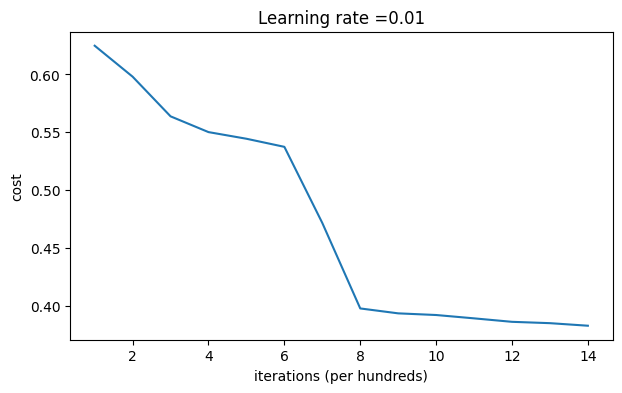

On the train set:
Accuracy: 0.83
On the test set:
Accuracy: 0.86


In [32]:
parameters = model(train_X, train_Y, initialization = "random")
print ("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

In [37]:
def initialize_parameters_he(layers_dims):
    np.random.seed(3)
    parameters = {}
    L = len(layers_dims) 

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1])*np.sqrt(2/layers_dims[l-1])
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))

    return parameters

Cost after interation 0 : 0.8830537463419761
Cost after interation 1000 : 0.6879825919728063
Cost after interation 2000 : 0.6751286264523371
Cost after interation 3000 : 0.6526117768893807
Cost after interation 4000 : 0.6082958970572938
Cost after interation 5000 : 0.5304944491717495
Cost after interation 6000 : 0.4138645817071795
Cost after interation 7000 : 0.31178034648444414
Cost after interation 8000 : 0.23696215330322565
Cost after interation 9000 : 0.18597287209206836
Cost after interation 10000 : 0.15015556280371808
Cost after interation 11000 : 0.12325079292273551
Cost after interation 12000 : 0.09917746546525935
Cost after interation 13000 : 0.08457055954024276
Cost after interation 14000 : 0.07357895962677363


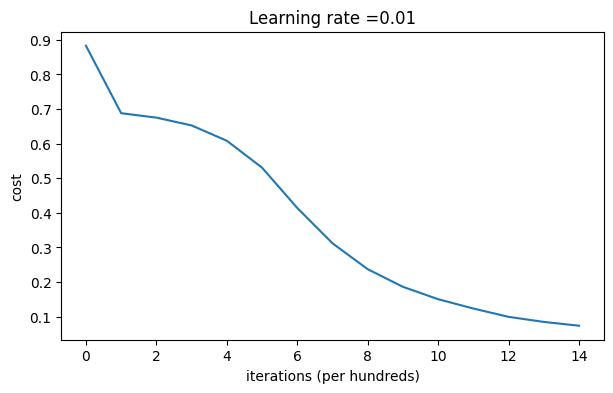

On the train set:
Accuracy: 0.9933333333333333
On the test set:
Accuracy: 0.96


In [38]:
parameters = model(train_X, train_Y, initialization = "he")
print ("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)